In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torchaudio
from torchmetrics.audio import SignalNoiseRatio
from utility_functions import add_background_noise, read_yaml_file
from torchmetrics.functional.audio import signal_noise_ratio as snr
from metrics import unified_metric

In [2]:
DATA_DIR = "/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/mmishra/Phd/SpatialScaper/output" # change this to your data directory

noise, noise_sr = torchaudio.load("/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/mmishra/Phd/S5/evaluation_metric_study/white_noise.wav")
noise = noise[0 , :]

mix_source_1_paths = {}
mix_source_2_paths = {}
mix_source_3_paths = {}
mix_source_4_paths = {}
mix_source_5_paths = {}
mix_paths = {}
mix_yamls = {}

for i in range(1, 501):
    idx = str(i).zfill(3)
    mix_source_1_paths[i] = os.path.join(DATA_DIR, f'foa/audio_mix_metu_2_{idx}/wet_source_1.wav')
    mix_source_2_paths[i] = os.path.join(DATA_DIR, f'foa/audio_mix_metu_2_{idx}/wet_source_2.wav')
    mix_source_3_paths[i] = os.path.join(DATA_DIR, f'foa/audio_mix_metu_2_{idx}/wet_source_3.wav')
    mix_source_4_paths[i] = os.path.join(DATA_DIR, f'foa/audio_mix_metu_2_{idx}/wet_source_4.wav')
    mix_source_5_paths[i] = os.path.join(DATA_DIR, f'foa/audio_mix_metu_2_{idx}/wet_source_5.wav')
    mix_paths[i] = os.path.join(DATA_DIR, f'foa/audio_mix_metu_2_{idx}/audio_mix_metu_2_{idx}.wav')
    mix_yamls[i] = os.path.join(DATA_DIR, f'yaml/audio_mix_metu_2_{idx}.yaml')


/home/mmishra/.local/lib/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/home/mmishra/.local/lib/python3.9/site-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more informa

In [3]:
SNR = SignalNoiseRatio()

def compare_separation_performance(alpha, case):

    base_metric_values = []
    metric_loria_values = []
    metric_ntt_values = []
        
    for i in range(1, 501):

        x , sr_mix= torchaudio.load(mix_paths[i])
        s1, sr_s1 = torchaudio.load(mix_source_1_paths[i])
        s2, sr_s2 = torchaudio.load(mix_source_2_paths[i])
        s3, sr_s3 = torchaudio.load(mix_source_3_paths[i])
        s4, sr_s4 = torchaudio.load(mix_source_4_paths[i])
        s5, sr_s5 = torchaudio.load(mix_source_5_paths[i])

        yaml_file = read_yaml_file(mix_yamls[i])

        onset_time_1 = yaml_file['foreground_events'][0]['event_time']
        onset_time_2 = yaml_file['foreground_events'][1]['event_time']
        onset_time_3 = yaml_file['foreground_events'][2]['event_time']
        onset_time_4 = yaml_file['foreground_events'][3]['event_time']
        onset_time_5 = yaml_file['foreground_events'][4]['event_time']

        offset_time_1 = yaml_file['foreground_events'][0]['event_time']+ yaml_file['foreground_events'][0]['event_duration']
        offset_time_2 = yaml_file['foreground_events'][1]['event_time']+ yaml_file['foreground_events'][1]['event_duration']
        offset_time_3 = yaml_file['foreground_events'][2]['event_time']+ yaml_file['foreground_events'][2]['event_duration']
        offset_time_4 = yaml_file['foreground_events'][3]['event_time']+ yaml_file['foreground_events'][3]['event_duration']
        offset_time_5 = yaml_file['foreground_events'][4]['event_time']+ yaml_file['foreground_events'][4]['event_duration']


        x = x[0 , :]
        s1 = s1[0 , :]
        s2 = s2[0 , :]
        s3 = s3[0 , :]
        s4 = s4[0 , :]
        s5 = s5[0 , :]


        start_idx_1 = int(onset_time_1 * sr_s1)
        end_idx_1 = int(offset_time_1*sr_s1)

        start_idx_2 = int(onset_time_2* sr_s2)
        end_idx_2 = int(offset_time_2*sr_s2)

        start_idx_3 = int(onset_time_3 * sr_s3)
        end_idx_3 = int(offset_time_3*sr_s3)

        start_idx_4 = int(onset_time_4 * sr_s4)
        end_idx_4 = int(offset_time_4*sr_s4)

        start_idx_5 = int(onset_time_5 * sr_s5)
        end_idx_5 = int(offset_time_5*sr_s5)

        
        ref_wf = [s1, s2, s3]

        noisy_wf = [add_background_noise(ref_wf[0], start_idx_1, end_idx_1, noise, snr_db=60), 
                   add_background_noise(ref_wf[1], start_idx_2, end_idx_2, noise, snr_db=60), 
                   add_background_noise(ref_wf[2],start_idx_3, end_idx_3, noise, snr_db=60),
                   add_background_noise(s4, start_idx_4, end_idx_4 , noise, snr_db=60),  
                   add_background_noise(s5, start_idx_5, end_idx_5, noise, snr_db=60)]

        if case == 1:
            e1 = (1-alpha) * noisy_wf[0] + (alpha) * x 
            e2 = (1-alpha) * noisy_wf[1] + (alpha) * x
            e3 = (1-alpha) * noisy_wf[2] + (alpha) * x
        
        elif case == 2:
            e1 = noisy_wf[0]
            e2 = noisy_wf[1]
            e3 = (1-alpha) * noisy_wf[2] + (alpha) * noisy_wf[3]

        elif case == 3:
            e1 = (1-alpha) * noisy_wf[0] + (alpha) * noisy_wf[1]
            e2 = (1-alpha) * noisy_wf[1] + (alpha) * noisy_wf[0]
            e3 = noisy_wf[2]    


        est_wf = [e1, e2, e3]

        ref_lb = [yaml_file['foreground_events'][0]['label'], yaml_file['foreground_events'][1]['label'], yaml_file['foreground_events'][2]['label']]
        est_lb = ref_lb.copy()  

        est_dict = {est_lb[0]: e1, est_lb[1]: e2, est_lb[2]: e3}
        ref_dict = {ref_lb[0]: s1, ref_lb[1]: s2, ref_lb[2]: s3}


        base_metric = unified_metric(metric_type='classical', mode='none', metricfunc=SNR, mixture=x, est_dict=est_dict, ref_dict=ref_dict)
        base_metric_values.append(base_metric)

        metric_loria_value, tps_casa, fns_casa, fps_casa = unified_metric(metric_type='casasdr', mode='source_wise', metricfunc=SNR, mixture=x, est_dict=est_dict, ref_dict=ref_dict)
        metric_loria_values.append(metric_loria_value.item())

        metric_ntt_value, tps_ca, fns_ca, fps_ca = unified_metric(metric_type='casdr', mode='error_wise', metricfunc=snr, mixture=x, est_dict=est_dict, ref_dict=ref_dict)
        metric_ntt_values.append(metric_ntt_value)
        
    return np.mean(base_metric_values), np.mean(metric_loria_values), np.mean(metric_ntt_values)


Processing alpha: 0
Processing alpha: 0.1
Processing alpha: 0.2
Processing alpha: 0.3
Processing alpha: 0.4
Processing alpha: 0.5
Processing alpha: 0.6
Processing alpha: 0.7
Processing alpha: 0.8
Processing alpha: 0.9
Processing alpha: 1


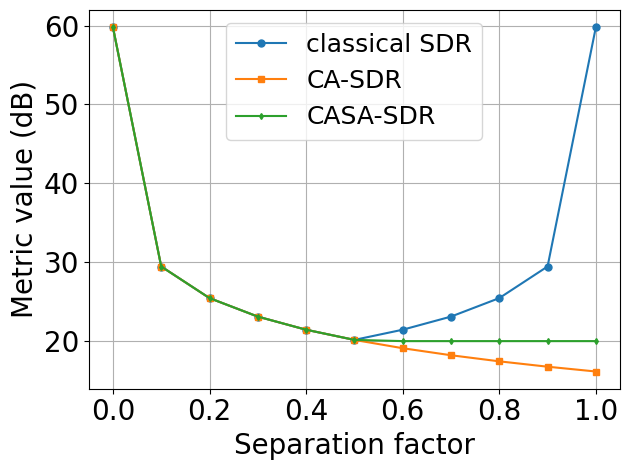

In [4]:
alpha_values = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
sdr_values = []
metric_loria_values = []
metric_ntt_values = []

for alpha in alpha_values:
        print(f"Processing alpha: {alpha}")
        sdr, loria, ntt = compare_separation_performance(alpha, case=3)
        sdr_values.append(sdr)
        metric_loria_values.append(loria)
        metric_ntt_values.append(ntt)

plt.plot(alpha_values, sdr_values, marker='o',  markersize= 5,label='classical SDR')
plt.plot(alpha_values, metric_ntt_values, marker='s', markersize= 4, label='CA-SDR')
plt.plot(alpha_values, metric_loria_values, marker='d', markersize= 3, label='CASA-SDR')

plt.xlabel("Separation factor", fontsize=20)
plt.ylabel("Metric value (dB)", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=18)
plt.grid(True)
plt.tight_layout()
plt.savefig(f"./impact_of_cross_contamination.pdf", bbox_inches='tight')
plt.show()